In [27]:
import pandas as pd
import numpy as np

In [28]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
api_key = user_secrets.get_secret("GENAI_T2_2026")

import wandb
wandb.login(key=api_key)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


True

In [29]:
train = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
test = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")

In [30]:
train.head()

,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


## Text cleaning methods:
Creating a function to convert the raw text data into cleaner text form by:

1. Lowercasing the texts
2. Removing any kind of special characters
3. Reducing multiple white spaces(if there) into one.

In [31]:
import re

def text_clean(text):
  lower_text = text.lower()
  simple_text = re.sub(r'[^a-z0-9\s]', '', lower_text)
  cleaned_text = re.sub(r'\s+', ' ', simple_text)
  return cleaned_text

In [32]:
#applying function to all the columns in both train and test
cols = ['prompt' , 'A', 'B' , 'C' , 'D' , 'E']

for col in cols:
    train[col +'_clean'] = train[col].apply(text_clean)
    test[col +'_clean'] = test[col].apply(text_clean)

In [33]:
train.head(1)

,id,prompt,A,B,C,D,E,answer,prompt_clean,A_clean,B_clean,C_clean,D_clean,E_clean
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B,pick the best possible answer what is martin h...,martin heidegger believes that humans exist wi...,martin heidegger believes that humans do not e...,martin heidegger does not believe in the exist...,martin heidegger believes that the relationshi...,martin heidegger believes that time is an illu...


In [34]:
train.shape

(2000, 14)

In [35]:
x = train.copy()

## Applying train test split on the dataset

In [36]:
from sklearn.model_selection import train_test_split

x_train, x_test = train_test_split(x, test_size=0.2, random_state=42)

In [37]:
x_train.shape, x_test.shape

((1600, 14), (400, 14))

In [38]:
#function to build prompt and option pairs

def build_pairs(df):
    rows = []
    for i in df.index:
        prompt = df.loc[i, 'prompt_clean']
        options = ['A', 'B', 'C', 'D', 'E']
        for opt in options:
            text = prompt + ' ' + df.loc[i, f'{opt}_clean']
            label = 0
            if df.loc[i, 'answer'] == opt:
                label = 1

            rows.append({'id': df.loc[i, 'id'],
                         'option': opt,
                         'text': text,
                         'label': label})
    return pd.DataFrame(rows)

train_pairs = build_pairs(x_train)
val_pairs = build_pairs(x_test)

print(train_pairs.shape, val_pairs.shape)

(8000, 4) (2000, 4)


In [39]:
train_pairs.iloc[0:5]

,id,option,text,label
0,969,A,pick the best possible answer what is the prop...,1
1,969,B,pick the best possible answer what is the prop...,0
2,969,C,pick the best possible answer what is the prop...,0
3,969,D,pick the best possible answer what is the prop...,0
4,969,E,pick the best possible answer what is the prop...,0


In [40]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(ngram_range=(1,2),
                    max_features=20000,
                        min_df = 2,
                        sublinear_tf = True)

In [41]:
x_train_tfidf = tfidf.fit_transform(train_pairs['text'])
x_test_tfidf = tfidf.transform(val_pairs['text'])

y_train_label = train_pairs['label']
y_test_label = val_pairs['label']

x_train_tfidf.shape

(8000, 13375)

In [42]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=5000 ,class_weight = 'balanced', random_state = 42)
lr.fit(x_train_tfidf, y_train_label)

LogisticRegression(class_weight='balanced', max_iter=5000, random_state=42)

In [43]:
def map_at3(prediction,correct):  #function to calculate MAP@3 score
  score = 0
  for pred, x in zip(prediction, correct):
    if x in pred:
      k = pred.index(x) + 1
      score += 1/k
  return round(score/len(correct) ,4)

In [44]:
val_pairs['prob'] = lr.predict_proba(x_test_tfidf)[:, 1]

def get_top3_predictions(pairs_df):
    predictions = []
    qids = []
    for qid, group in pairs_df.groupby('id'):
        top3 = group.sort_values('prob', ascending=False)['option'].tolist()[:3]
        predictions.append(top3)
        qids.append(qid)
    return predictions, qids

val_top3, val_qids = get_top3_predictions(val_pairs)
actual_answers = x_test.set_index('id').loc[val_qids, 'answer'].tolist()

score = map_at3(val_top3, actual_answers)
print("TF-IDF + Logistic Regression MAP@3:", score)

TF-IDF + Logistic Regression MAP@3: 0.9879


In [45]:
val_pairs.iloc[:10]

,id,option,text,label,prob
0,1861,A,select the most accurate option what is the pr...,0,0.336390
1,1861,B,select the most accurate option what is the pr...,0,0.269219
2,1861,C,select the most accurate option what is the pr...,0,0.416296
3,1861,D,select the most accurate option what is the pr...,1,0.614132
4,1861,E,select the most accurate option what is the pr...,0,0.443478
5,354,A,pick the best possible answer what is the most...,0,0.231160
6,354,B,pick the best possible answer what is the most...,0,0.319759
7,354,C,pick the best possible answer what is the most...,0,0.205278
8,354,D,pick the best possible answer what is the most...,0,0.255083
9,354,E,pick the best possible answer what is the most...,1,0.721028


## Classification Metrics (Precision, Recall, F1)

We check Precision, Recall, and F1 on the validation pairs to check model's performance

In [46]:
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_binary = lr.predict(x_test_tfidf)

print(classification_report(y_test_label, y_pred_binary, 
                            target_names=['Incorrect Option','Correct Option']))

f1 = f1_score(y_test_label, y_pred_binary)
print(f"F1 Score: {f1:.4f}")

                  precision    recall  f1-score   support

Incorrect Option       0.99      0.95      0.97      1600
  Correct Option       0.83      0.98      0.90       400

        accuracy                           0.96      2000
       macro avg       0.91      0.96      0.94      2000
    weighted avg       0.96      0.96      0.96      2000

F1 Score: 0.8991


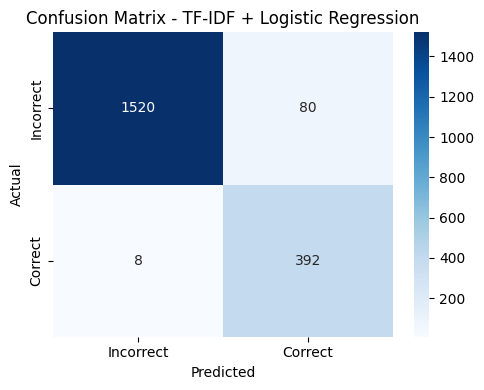

In [47]:
# Confusion matrix - shows how well the model distinguishes correct vs incorrect options
cm = confusion_matrix(y_test_label, y_pred_binary)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Incorrect','Correct'], yticklabels=['Incorrect','Correct'])
plt.title('Confusion Matrix - TF-IDF + Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## WandB Experiment Tracking

In [48]:
wandb.init(project="23f2003665-t22026", name="baselines")

wandb.log({
    "majority_baseline_map3": 0.4213,
    "random_baseline_map3": 0.3675,
    "cosine_similarity_map3": 0.3265,
})

wandb.finish()

cosine_similarity_map3,▁
majority_baseline_map3,▁
random_baseline_map3,▁
cosine_similarity_map3,0.3265
majority_baseline_map3,0.4213
random_baseline_map3,0.3675


In [49]:
wandb.init(
    project="23f2003665-t22026",
    name="tfidf-lr-v1",
    config={
        "model": "TF-IDF + Logistic Regression",
        "ngram_range": "(1,2)",
        "min_df": 2,
        "max_features": 50000,
        "class_weight": "balanced",
        "train_questions": int(x_train['id'].nunique()),
        "val_questions": int(x_test['id'].nunique()),
    }
)

wandb.log({
    "val_map3": score,
    "f1_score": round(f1, 4),
})

wandb.finish()

f1_score,▁
val_map3,▁
f1_score,0.8991
val_map3,0.9879


## Generate Kaggle Submission

Same pipeline as validation, applied to the test set (no answers available, so no
MAP@3 here - just predictions). Wrapped into reusable functions so the same pattern
can be reused later for the BERT and LoRA models.

In [50]:
def build_test_pairs(df): #Creates one row per (question, option) pair for the test set.
    rows = []
    for i in df.index:
        prompt =df.loc[i,'prompt_clean']
        
        for opt in ['A','B','C','D','E']:
            text= prompt + ' ' + df.loc[i, f'{opt}_clean']
            rows.append({'id': df.loc[i, 'id'], 
                         'option': opt, 
                         'text': text})
            
    return pd.DataFrame(rows)
    

#full process redone on the test pair
def generate_submission(model,vectorizer,test_df,filename='submission.csv'): 
    test_pairs = build_test_pairs(test_df)
    test_pairs['prob'] = model.predict_proba(vectorizer.transform(test_pairs['text']))[:, 1]

    predictions,qids = [],[]
    for qid,group in test_pairs.groupby('id'):
        top3 = group.sort_values('prob', ascending=False)['option'].tolist()[:3]
        predictions.append(' '.join(top3))
        qids.append(qid)

    submission = pd.DataFrame({'id': qids,
                               'prediction': predictions})
    
    submission.to_csv(filename, index=False)
    return submission


submission = generate_submission(lr, tfidf, test)
print(f"Submission shape: {submission.shape}")
submission.head()

Submission shape: (500, 2)


,id,prediction
0,1,A E B
1,2,B C E
2,3,B E D
3,4,E C A
4,5,C A D


In [52]:
import joblib

joblib.dump(lr, '/kaggle/working/tfidf_lr_model.pkl')

['/kaggle/working/tfidf_lr_model.pkl']